# Nearly-Periodic Coupled Oscillators: Reference Trajectory Analysis and Validation

## Overview

This notebook provides analysis and validation of the reference trajectories generated by numerical simulations of the nearly-periodic coupled oscillators (NPCO) problem.

In particular, this notebook will:
1. Load and visualize reference trajectories for different initial conditions
2. Compute Taylor series approximations and compare against high-accuracy reference solutions

## Mathematical Model

The system is described by the Hamiltonian:

$$ H_\varepsilon (q_1,q_2,p_1,p_2) = \frac{1}{2} (q_1^2 + p_1^2 ) + \frac{1}{2} \varepsilon (q_2^2 + p_2^2 )  + \varepsilon U(q_1,q_2) $$

where the coupling potential is:
$$ U(q_1,q_2) = q_1 q_2 \sin(2q_1 + 2q_2) $$

The equations of motion are:
$$ \begin{cases} \dot{q}_1 = p_1 \qquad & \dot{p}_1 = -q_1 - \varepsilon \partial_{q_1} U(q_1,q_2) \\ \dot{q}_2 = \varepsilon p_2 \qquad & \dot{p}_2 = -\varepsilon q_2 - \varepsilon \partial_{q_2} U(q_1,q_2)
\end{cases} $$

This system exhibits interesting dynamics with coupling parameter $\varepsilon$ controlling the strength of interaction between the oscillators.

## Setup and Dependencies 

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np

from notebook_utils.dataprocessing import NCO, NCOTrajectory, NCODataset
from notebook_utils.visualization import NCOVisualizer

Trajectory = NCOTrajectory
Dataset = NCODataset

viz = NCOVisualizer()

## Analysis


### 1. Constant Energy Trajectories

We analyze three reference trajectories with constant total energy but different initial conditions:
- Trajectory 1: $(q_1, q_2, p_1, p_2) = (0, 0, 1.5, 1.5)$
- Trajectory 2: $(q_1, q_2, p_1, p_2) = (0, 0, -1.45433, 5.0)$
- Trajectory 3: $(q_1, q_2, p_1, p_2) = (0, 0, 1.0, 11.45256)$

Initial conditions for each trajectory:
Trajectory 1: [0.  0.  1.5 1.5] H=1.1299631512905242
Trajectory 2: [ 0.       0.      -1.45433  5.     ] H=1.1299628556036527
Trajectory 3: [ 0.       0.       1.      11.45256] H=1.129961719857544


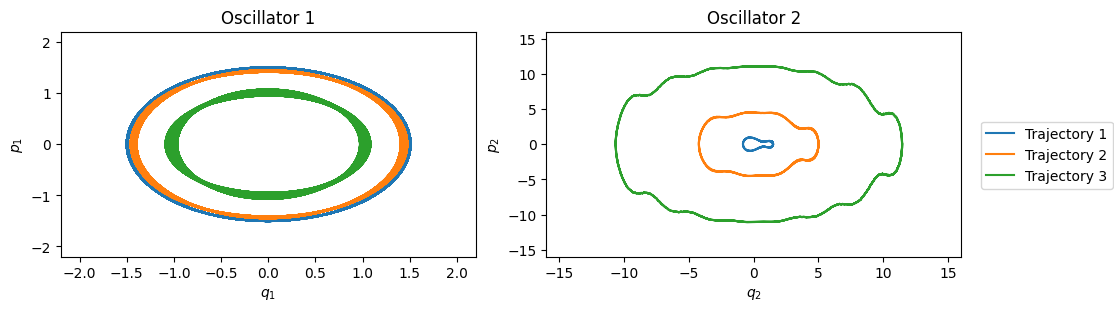

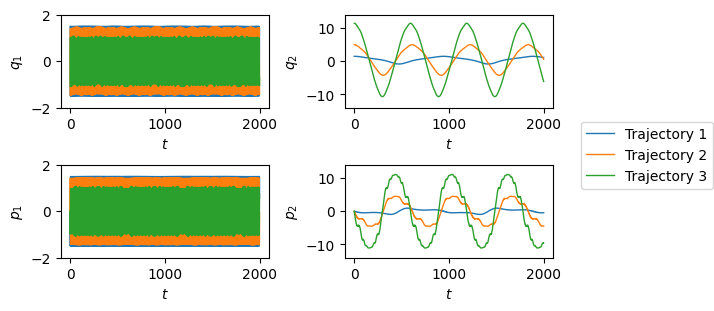

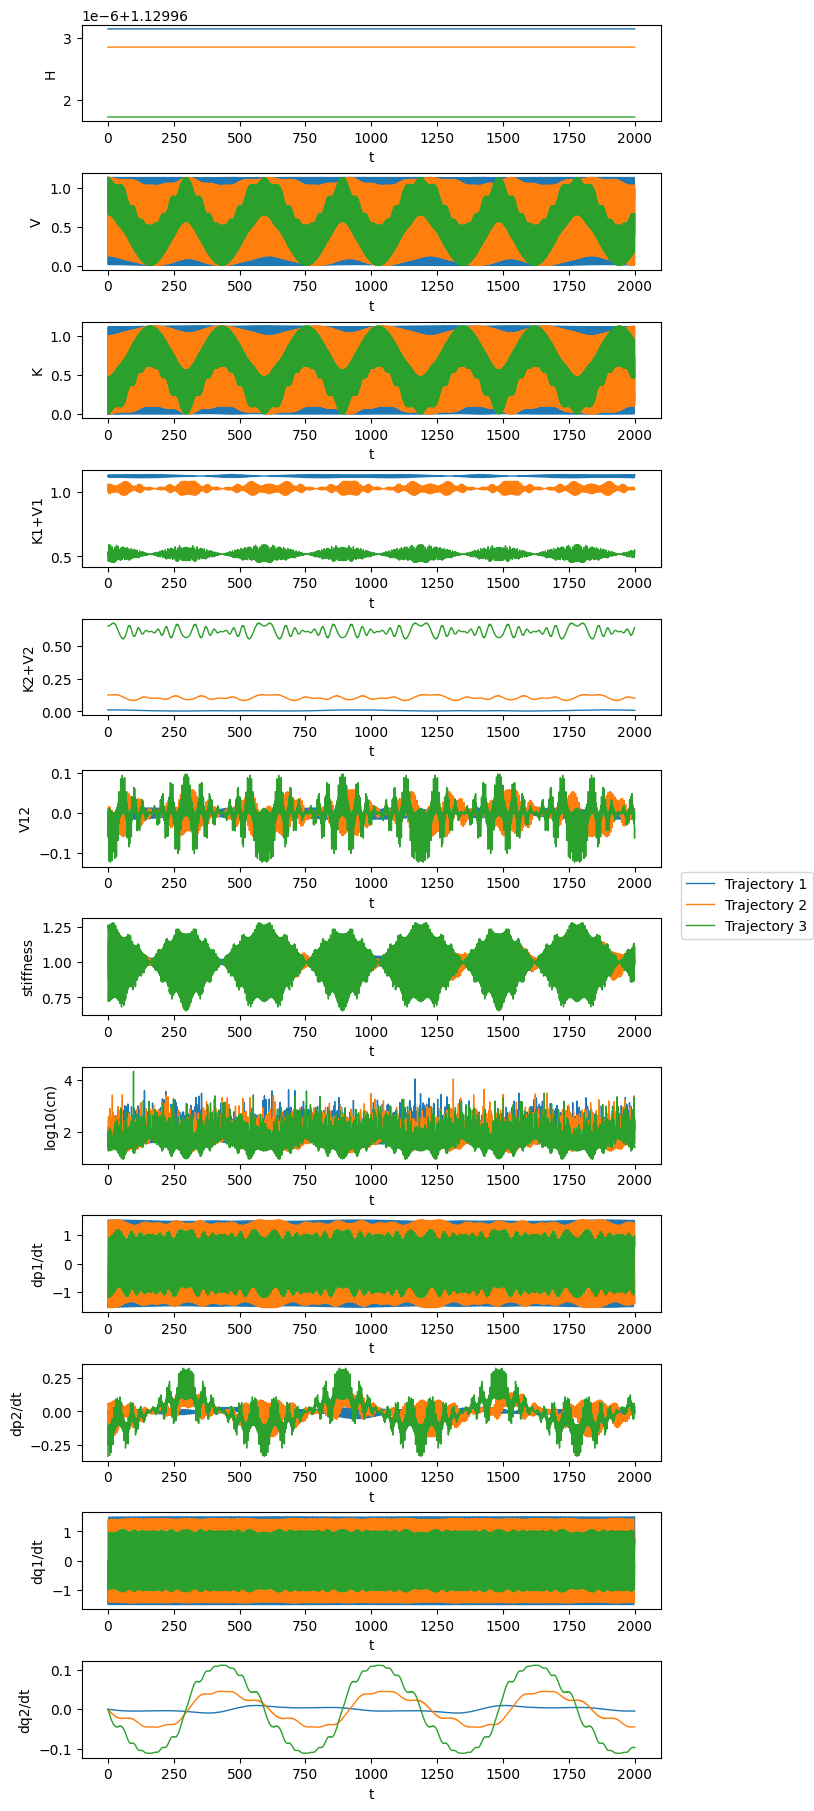

In [2]:
# Set parameter
epsilon = 0.01

# Define trajectory indices and labels
traj_indices = [1, 2, 3]
traj_labels = ["Trajectory {}".format(i) for i in traj_indices]

# Get reference trajectory filepaths
ref_filepaths = NCO.get_reference_filepaths("constant_energy")

# Load reference trajectories
ref_trajs = [
    Trajectory.load_from_file(
        ref_filepaths[epsilon][i]["filepath"], 
        dt=ref_filepaths[epsilon][i]["dt"],
        epsilon=epsilon,) 
    for i in traj_indices
]

# Create processor for computing derivatives and energies
processor = NCO(epsilon=epsilon)

# Display initial conditions for verification
print("Initial conditions for each trajectory:")
for i, traj in enumerate(ref_trajs):
    print(f"Trajectory {i+1}: {traj.states.u[0]} H={processor.compute_hamiltonian(traj.states.u[0])}")

# Select time window for analysis (t = 0 to 5000)
trajs = [traj.select_between(0, 5000) for traj in ref_trajs]

# Plot trajectories in phase space
viz.plot_phase_space(
    trajs, 
    axis_lims=[((-2.2, 2.2), (-2.2, 2.2)), ((-16, 16), (-16, 16))],
    legend_labels=traj_labels, 
    show_legend=True,
    figsize=(11, 3)
)
# Plot position and momentum vs time
viz.plot_pq_vs_t(
    trajs, 
    ylims=[(-2, 2), (-14, 14), (-2, 2), (-14, 14)],
    figsize=(7, 3), 
    legend_labels=traj_labels,
    show_legend=True,
)

# Plot the time series of various quantities
viz.plot_history(
    trajs,
    func_dict={
        "H": processor.compute_hamiltonian,
        "V": processor.compute_potential_energy,
        "K": processor.compute_kinetic_energy,
        "K1+V1": lambda u: processor.compute_energies(u)["K1+V1"],
        "K2+V2": lambda u: processor.compute_energies(u)["K2+V2"],
        "V12": processor.compute_interaction_energy,
        "stiffness": processor.compute_stiffness2,
        "log10(cn)": lambda u: np.log10(processor.compute_stiffness2(u, ratio=True)),
        "dp1/dt": lambda u: processor.compute_du(u)[:, 0],
        "dp2/dt": lambda u: processor.compute_du(u)[:, 1],
        "dq1/dt": lambda u: processor.compute_du(u)[:, 2],
        "dq2/dt": lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t', 
    legend_labels=traj_labels,
    show_legend=True
)


In [5]:
viz.plot_phase_space_matlab(
    trajs, 
    axis_lims=[((-2, 2), (-2, 2)), ((-14, 14), (-14, 14))],
    legend_labels=traj_labels, 
    show_legend=False,
    figsize=(5,2),
    save_path=f"./out/nco/eps=1e-2/phase_space_ref_fixedH.pdf"
)

Current figure size: 5.0" x 2.0"
New figure size: 5.0" x 2.0"
Saved figure as: ./out/nco/eps=1e-2/phase_space_ref_fixedH.pdf and ./out/nco/eps=1e-2/phase_space_ref_fixedH.fig


### 2. Fixed q₁ Trajectories

To investigate the effect of different initial conditions, we analyze trajectories with fixed initial $q_1$ but varying initial $q_2$:
- Trajectory 1: $(p_1, p_2, q_1, q_2) = (0, 0, 1.5, 0.0)$
- Trajectory 2: $(p_1, p_2, q_1, q_2) = (0, 0, 1.5, 0.15)$
- Trajectory 3: $(p_1, p_2, q_1, q_2) = (0, 0, 1.5, 0.3)$
- Trajectory 4: $(p_1, p_2, q_1, q_2) = (0, 0, 1.5, 0.4)$
- Trajectory 5: $(p_1, p_2, q_1, q_2) = (0, 0, 1.5, 1.0)$
- Trajectory 6: $(p_1, p_2, q_1, q_2) = (0, 0, 1.5, 1.45)$
- Trajectory 7: $(p_1, p_2, q_1, q_2) = (0, 0, 1.5, 1.55)$


Initial conditions for each trajectory:
Trajectory 1: [0.  0.  1.5 0. ] H=1.125
Trajectory 2: [0.   0.   1.5  0.15] H=1.1247575721881777
Trajectory 3: [0.  0.  1.5 0.3] H=1.1234586580051733
Trajectory 4: [0.  0.  1.5 0.4] H=1.1221288526543436
Trajectory 5: [0.  0.  1.5 1. ] H=1.1156161358800527
Trajectory 6: [0.   0.   1.5  1.45] H=1.1273806825399424
Trajectory 7: [0.   0.   1.5  1.55] H=1.1327772217756737
Trajectory 8: [0.  0.  1.5 4. ] H=1.1450005876069578
Trajectory 9: [0.  0.  1.5 5. ] H=1.281512527761998
Trajectory 10: [0.  0.  1.5 6. ] H=1.3635259056141404
Trajectory 11: [0.  0.  1.5 9. ] H=1.6429485112023676


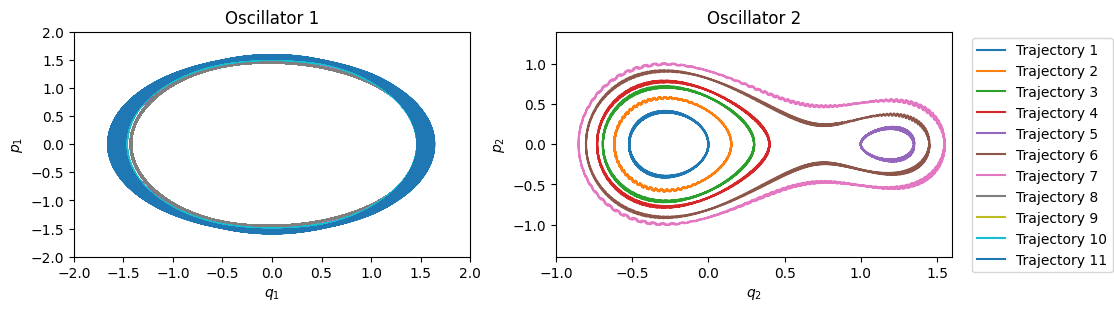

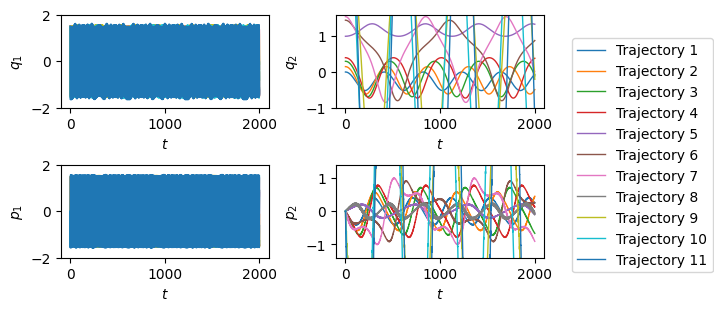

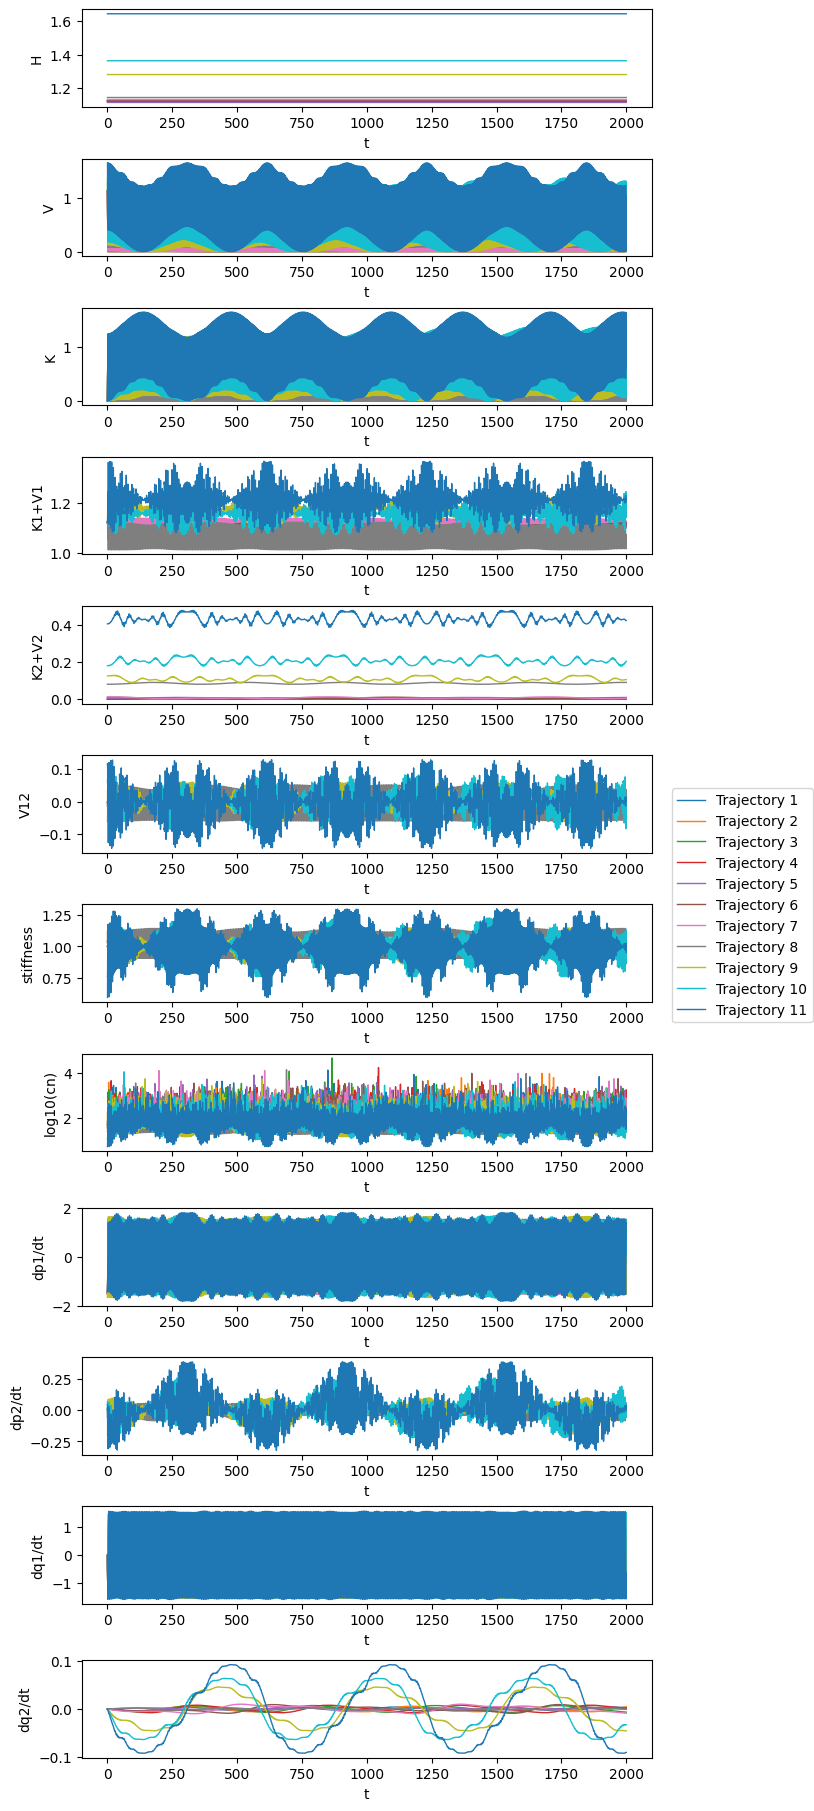

In [3]:
# Set parameter
epsilon = 0.01

# Define trajectory indices and labels
traj_indices = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
traj_labels = ["Trajectory {}".format(i) for i in traj_indices]

# Get reference trajectory filepaths
ref_filepaths = NCO.get_reference_filepaths("fixed_q1")

# Load reference trajectories
ref_trajs = [
    Trajectory.load_from_file(
        ref_filepaths[epsilon][i]["filepath"], 
        dt=ref_filepaths[epsilon][i]["dt"],
        epsilon=epsilon,) 
    for i in traj_indices
]

# Create processor for computing derivatives and energies
processor = NCO(epsilon=epsilon)

# Display initial conditions for verification
print("Initial conditions for each trajectory:")
for i, traj in enumerate(ref_trajs):
    print(f"Trajectory {i+1}: {traj.states.u[0]} H={processor.compute_hamiltonian(traj.states.u[0])}")

# Select time window for analysis (t = 0 to 2000)
trajs = [traj.select_between(0, 2000) for traj in ref_trajs]

# Plot trajectories in phase space
viz.plot_phase_space(
    trajs, 
    axis_lims=[((-2, 2), (-2, 2)), ((-1, 1.6), (-1.4, 1.4))],
    legend_labels=traj_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot position and momentum vs time
viz.plot_pq_vs_t(
    trajs, 
    ylims=[(-2, 2), (-1, 1.6), (-2, 2), (-1.4, 1.4)],
    figsize=(7, 3), 
    legend_labels=traj_labels,
    show_legend=True,
)

# Plot the time series of various quantities
viz.plot_history(
    trajs,
    func_dict={
        "H": processor.compute_hamiltonian,
        "V": processor.compute_potential_energy,
        "K": processor.compute_kinetic_energy,
        "K1+V1": lambda u: processor.compute_energies(u)["K1+V1"],
        "K2+V2": lambda u: processor.compute_energies(u)["K2+V2"],
        "V12": processor.compute_interaction_energy,
        "stiffness": processor.compute_stiffness,
        "log10(cn)": lambda u: np.log10(processor.compute_stiffness2(u, ratio=True)),
        "dp1/dt": lambda u: processor.compute_du(u)[:, 0],
        "dp2/dt": lambda u: processor.compute_du(u)[:, 1],
        "dq1/dt": lambda u: processor.compute_du(u)[:, 2],
        "dq2/dt": lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t', 
    legend_labels=traj_labels,
    show_legend=True
)


In [8]:
viz.plot_phase_space_matlab(
    trajs, 
    axis_lims=[((-2, 2), (-2, 2)), ((-1, 1.6), (-1.4, 1.4))],
    legend_labels=traj_labels, 
    show_legend=False,
    figsize=(5,2),
    save_path=f"./out/nco/eps=1e-2/phase_space_ref_fixedq1.pdf"
)

Current figure size: 5.0" x 2.0"
New figure size: 5.0" x 2.0"
Saved figure as: ./out/nco/eps=1e-2/phase_space_ref_fixedq1.pdf and ./out/nco/eps=1e-2/phase_space_ref_fixedq1.fig


### 3. Taylor Series Approximation Validation

We generate Taylor series approximations of orders 0, 1, and 2 around $t=0$ for the NCO dynamics. We validate the computed approximations by comparing against reference trajectory over short time interval ($t$ from 0 to 40).

Physical significance: 
- Order 0: Constant approximation (initial state)
- Order 1: Linear approximation captures initial velocity direction
- Order 2: Quadratic approximation including acceleration effects
- Error Analysis: Reveals limitations of local approximations for long-time integration

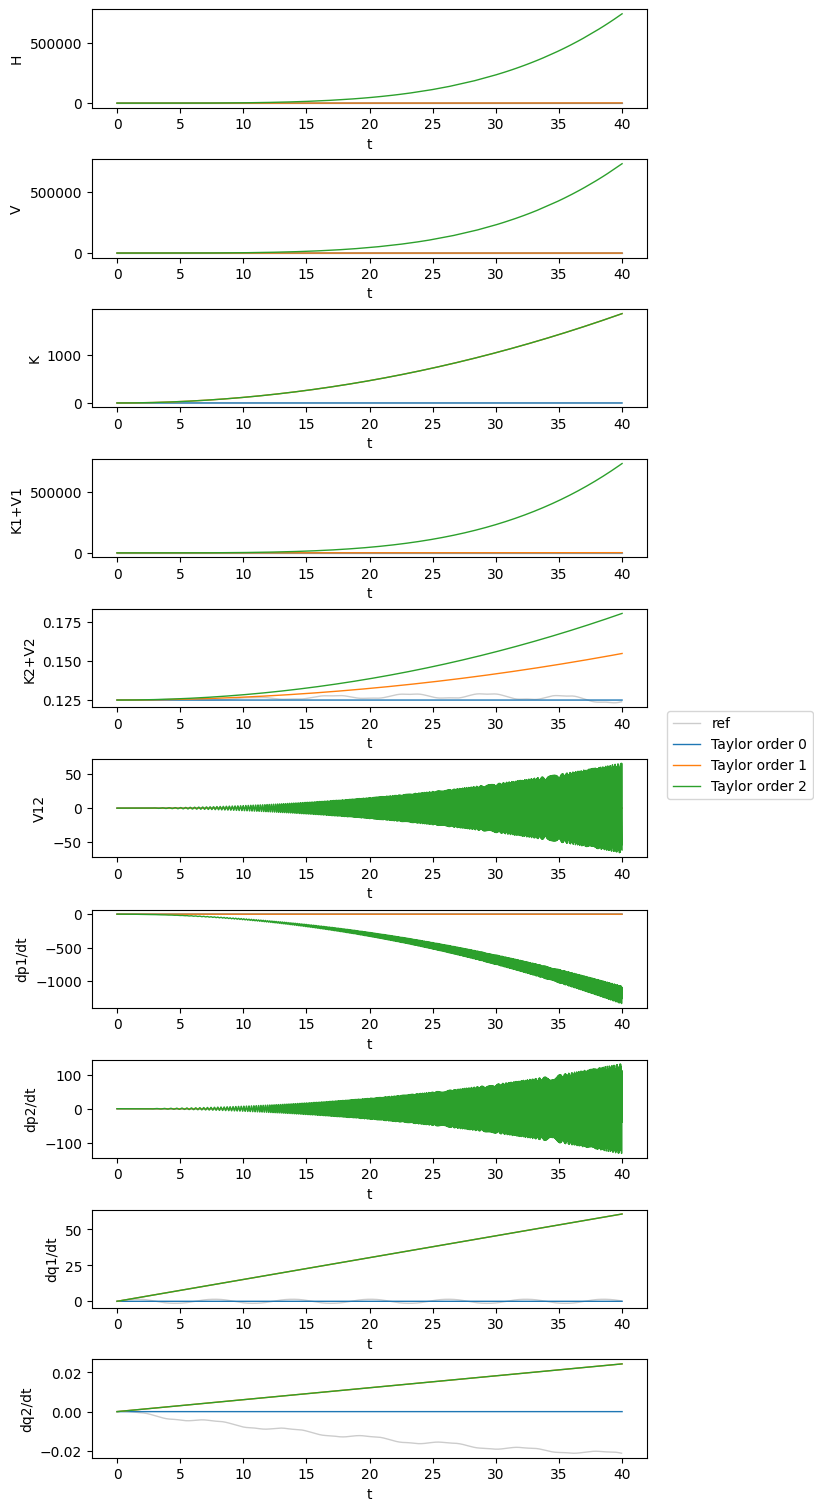

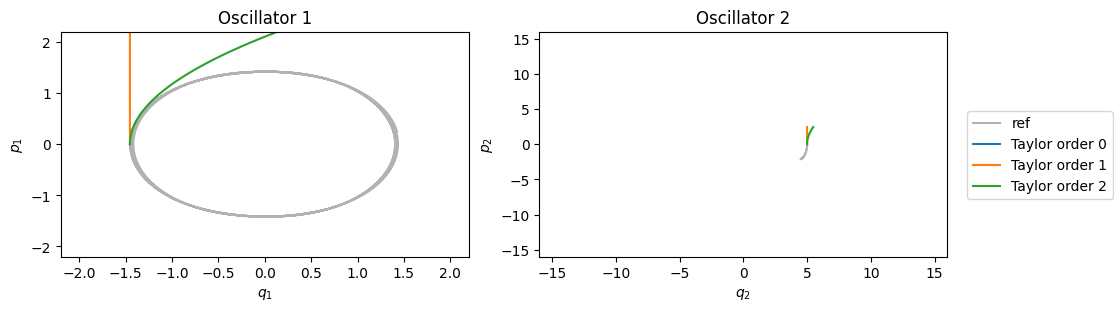

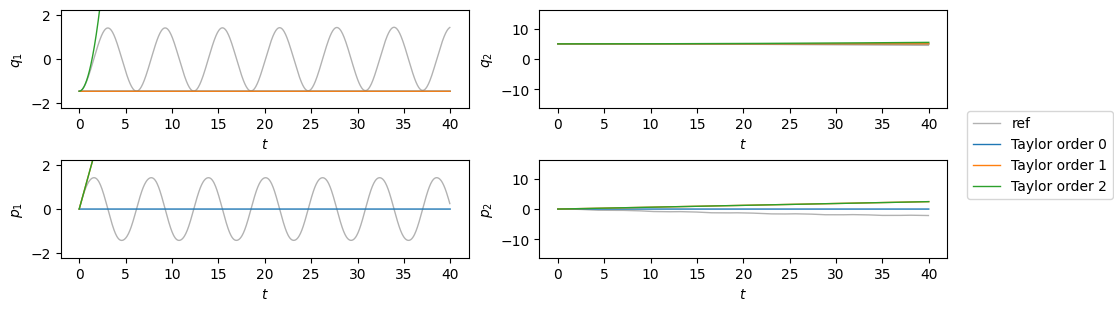

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 39.95], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(800, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 39.95], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(800, 4)))
Taylor order 0 n=1 osc1_rel_traj_err = 0.05219528953492113
Taylor order 0 n=799 osc1_rel_traj_err = 1.9971781060264484
Taylor order 0 n=1 osc2_rel_traj_err = 0.0006081628726052972
Taylor order 0 n=799 osc2_rel_traj_err = 0.43836384185783905
Taylor order 0 n=1 rel_traj_err = 0.014590153175547899
Taylor order 0 n=799 rel_traj_err = 0.6987474988200169
Taylor order 0 n=1 abs_H_err = 0.0
Taylor order 0 n=799 abs_H_err = 3.1086244689504383e-15
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 39.95], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(800, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 39.95], dt=0.05, u0

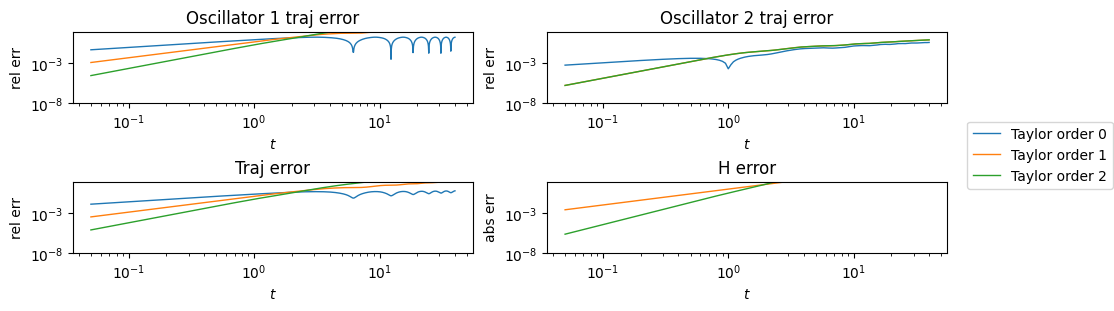

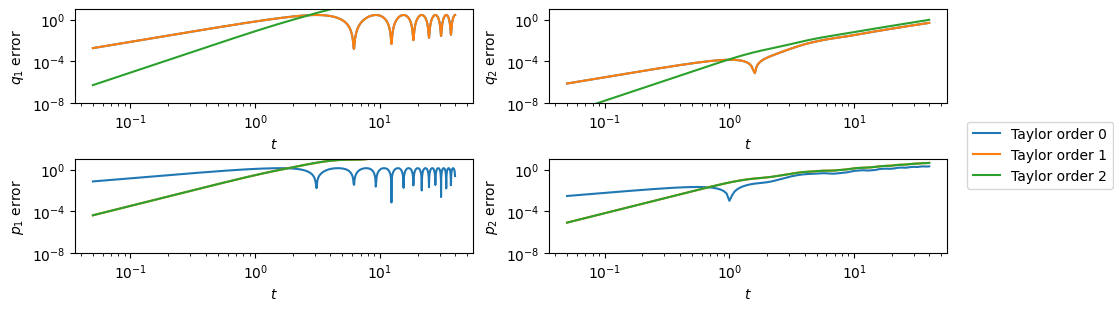

In [4]:
# Define function to generate Taylor approximations
def trajectory_from_taylor_expansion(u0, times, p, order):
    processor = NCO(**p)
    u = processor.compute_taylor_series(u0, times, order)
    return Trajectory.from_vx(times, u, **p)

# Set parameter
epsilon = 0.01
params = {"epsilon": epsilon}

# Set initial condition index
ref_traj_idx = 2

# Get reference trajectory filepaths
ref_filepaths = NCO.get_reference_filepaths("constant_energy")

# Load reference trajectory
ref_traj = Trajectory.load_from_file(
    ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[epsilon][ref_traj_idx]["dt"],
    **params
)
u0 = ref_traj.states.u[0]

# Define time range for Taylor analysis
t_list = np.arange(0, 40., 0.01)

# Generate Taylor approximations
taylor_trajs = [trajectory_from_taylor_expansion(u0, t_list, params, order) for order in [0, 1, 2]]
taylor_labels = [f"Taylor order {order}" for order in [0, 1, 2]]

# Create processor for analysis
processor = NCO(**params)

# Plot the time series of various quantities
viz.plot_history(
    [ref_traj.select_between(t_list.min(), t_list.max())] + taylor_trajs,
    func_dict={
        "H": processor.compute_hamiltonian,
        "V": processor.compute_potential_energy,
        "K": processor.compute_kinetic_energy,
        "K1+V1": lambda u: processor.compute_energies(u)["K1+V1"],
        "K2+V2": lambda u: processor.compute_energies(u)["K2+V2"],
        "V12": processor.compute_interaction_energy,
        "dp1/dt": lambda u: processor.compute_du(u)[:, 0],
        "dp2/dt": lambda u: processor.compute_du(u)[:, 1],
        "dq1/dt": lambda u: processor.compute_du(u)[:, 2],
        "dq2/dt": lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t', 
    legend_labels=["ref"] + taylor_labels,
    show_legend=True
)

# Plot trajectories in phase space
viz.plot_phase_space(
    [ref_traj.select_between(t_list.min(), t_list.max())] + taylor_trajs, 
    axis_lims=[((-2.2, 2.2), (-2.2, 2.2)), ((-16, 16), (-16, 16))],
    legend_labels=["ref"] + taylor_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot position and momentum vs time
viz.plot_pq_vs_t(
    [ref_traj.select_between(t_list.min(), t_list.max())] + taylor_trajs, 
    ylims=[(-2.2, 2.2), (-16, 16), (-2.2, 2.2), (-16, 16)],
    legend_labels=["ref"] + taylor_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot errors
viz.plot_errors(
    taylor_trajs, ref_traj, 
    ylims=[(1e-8, 1e1)] * 4,
    legend_labels=taylor_labels, 
    show_legend=True,
    log_xscale=True,
    figsize=(11, 3)
)

# Plot position/momentum errors
viz.plot_pq_errors(
    taylor_trajs, ref_traj, 
    ylims=[(1e-8, 1e1)] * 4,
    legend_labels=taylor_labels, 
    show_legend=True,
    log_xscale=True,
    figsize=(11, 3)
)


In [5]:
viz.plot_errors_matlab(
    taylor_trajs, ref_traj, 
    ylims=[(1e-8, 1e1)] * 4,
    legend_labels=taylor_labels, 
    show_legend=True,
    log_xscale=True,
    figsize=(11, 6),
    save_path=f"./out/nco/eps=1e-2/taylor_errors_fixedH.pdf"
)

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 39.95], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(800, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 39.95], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(800, 4)))
Taylor order 0 n=1 osc1_abs_traj_err = 0.0759135335984007
Taylor order 0 n=799 osc1_abs_traj_err = 2.891339066369026
Taylor order 0 n=1 osc2_abs_traj_err = 0.0030408153883367825
Taylor order 0 n=799 osc2_abs_traj_err = 2.18208628481376
Taylor order 0 n=1 abs_traj_err = 0.07597441109756269
Taylor order 0 n=799 abs_traj_err = 3.622339320257564
Taylor order 0 n=1 abs_H_err = 0.0
Taylor order 0 n=799 abs_H_err = 3.1086244689504383e-15
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 39.95], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(800, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 39.95], dt=0.05, u0=[ 0.  

### 4. Given Target $H$, Find Unknown Variable

Uses root finding algorithms to solve the equation $H(q_1, q_2, p_1, p_2) = H_{\text{target}}$ for one unknown variable when the other three are specified.

In [5]:
from scipy.optimize import fsolve

def find_unknown(H, target_H, knowns, unknown_var):
    """
    Find the unknown variable in the equation H(v1, v2, x1, x2) = target_H.

    Args:
    - H (callable): The function H(v1, v2, x1, x2).
    - target_H (float): The known value of H.
    - knowns (dict): A dictionary with keys as variable names and values as their values. Should contain exactly three items.
    - unknown_var (str): The name of the unknown variable (one of 'v1', 'v2', 'x1', 'x2').

    Returns:
    - float: The computed value of the unknown variable that makes H equal to target_H.
    """
    # Check input validity
    assert len(knowns) == 3 and unknown_var not in knowns, "There must be exactly three known variables."

    # Define the function to find the root
    def func(unknown):
        vars = knowns.copy()
        vars[unknown_var] = unknown[0]
        inputs = np.array([vars['v1'], vars['v2'], vars['x1'], vars['x2']])
        return H(inputs) - target_H

    # Initial guess for the unknown
    initial_guess = [0.1]

    # Solve for the unknown
    solution = fsolve(func, initial_guess)
    error = func(solution)

    return solution[0], error

In [6]:
# Known values and target
target_value = NCO().compute_hamiltonian(np.array([[0.0, 0.0, 1.5, 1.5]]))[0]
known_values = {"v1": 1.0, "x1": 0.0, "x2": 0.0}
print(f"Target value of H is: {target_value}")
print(f"Known values are: {known_values}")

# Find unknown 
unknown_var = "v2"
result, error = find_unknown(lambda u: NCO().compute_hamiltonian(u), target_value, known_values, unknown_var)
print(f"The value of {unknown_var} that satisfies the equation is: {result}")
print(f"The error (residual) of the solution is: {error}")

Target value of H is: 1.1299631512905242
Known values are: {'v1': 1.0, 'x1': 0.0, 'x2': 0.0}
The value of v2 that satisfies the equation is: 0.11224643881126242
The error (residual) of the solution is: -2.220446049250313e-16


### 5. $(q_2, p_2)$ Level Sets

This analysis visualizes the level sets of the averaged Hamiltonian in the $(q_2, p_2)$ plane.

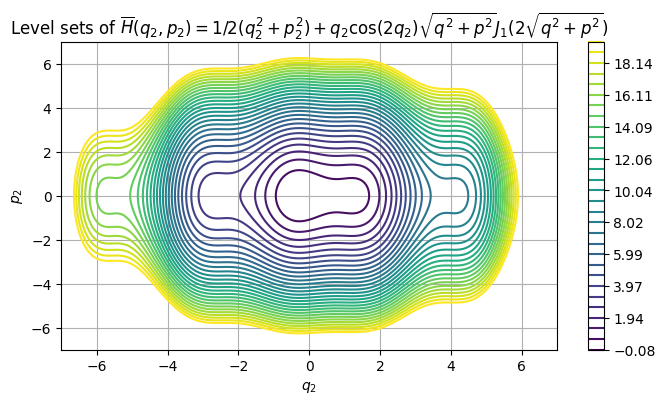

In [7]:
from scipy.special import j1
import matplotlib.pyplot as plt


def averaged_hamiltonian(q2, p2, q, p):
    r = np.sqrt(q**2 + p**2)
    fac = r * j1(2*r)
    return 0.5 * (q2**2 + p2**2) + q2 * np.cos(2 * q2) * fac

# Create a grid of (q2, p2) values
q2 = np.linspace(-7, 7, 400)
p2 = np.linspace(-7, 7, 400)
Q, P = np.meshgrid(q2, p2)

# Calculate H_bar for each (q2, p2) pair
H = averaged_hamiltonian(Q, P, q=1.5, p=0)

# Plot the level sets
plt.figure(figsize=(8, 4))
levels = np.linspace(H.min(), H.max()-30, 30)
# levels = [0., 0.084, 0.171, 0.222, 0.288, 0.335, 0.414, 4., 10.]
contour = plt.contour(Q, P, H, levels=levels, cmap='viridis')
plt.colorbar(contour)
plt.title('Level sets of $\overline{H}(q_2, p_2) = 1/2 (q_2^2 + p_2^2) + q_2 \cos(2q_2) \sqrt{q^2 + p^2} J_1(2\sqrt{q^2 + p^2})$')
plt.xlabel('$q_2$')
plt.ylabel('$p_2$')
plt.grid(True)
plt.show()

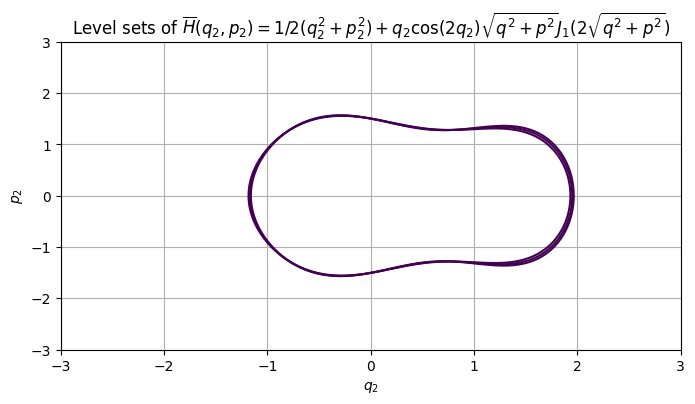

In [8]:
E = 1.129

q2 = np.linspace(-3, 3, 400)
p2 = np.linspace(-3, 3, 400)
Q, P = np.meshgrid(q2, p2)

plt.figure(figsize=(8, 4))

for (q, p) in [(1.5, 0), (-1.45, 0), (1., 0)]: 
    H = averaged_hamiltonian(Q, P, q=q, p=p)
    contour = plt.contour(Q, P, H, levels=[E], cmap='viridis')
    # plt.colorbar(contour)
plt.title('Level sets of $\overline{H}(q_2, p_2) = 1/2 (q_2^2 + p_2^2) + q_2 \cos(2q_2) \sqrt{q^2 + p^2} J_1(2\sqrt{q^2 + p^2})$')
plt.xlabel('$q_2$')
plt.ylabel('$p_2$')
plt.grid(True)
plt.show()